# EDA – CHRONO24 PRICE PREDICTION MODELS

# Load Data and Inspect

In [1]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

path = kagglehub.dataset_download("philmorekoung11/luxury-watch-listings")
print(f"Dataset downloaded to: {path}")

import os
for f in os.listdir(path):
    print(f)

df = pd.read_csv(f"{path}/Watches.csv")

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values (%):\n{(df.isnull().sum() / len(df) * 100).round(2)}")
print(f"\nFull duplicates: {df.duplicated().sum()}")
df.head()

100%|██████████| 6.71M/6.71M [00:00<00:00, 131MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/philmorekoung11/luxury-watch-listings/versions/1
Watches.csv


/tmp/ipykernel_447/3993534404.py:16: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/Watches.csv")


Shape: (284491, 14)

Dtypes:
Unnamed: 0     int64
name          object
price         object
brand         object
model         object
ref           object
mvmt          object
casem         object
bracem        object
yop           object
cond          object
sex           object
size          object
condition     object
dtype: object

Missing values (%):
Unnamed: 0     0.00
name          25.51
price          0.14
brand          0.05
model         10.71
ref           15.17
mvmt          69.14
casem         57.74
bracem        61.48
yop            0.05
cond          26.71
sex           33.68
size           8.29
condition     74.84
dtype: float64

Full duplicates: 0


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


In [2]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].dropna().unique()[:10])


--- Unnamed: 0 ---
[0 1 2 3 4 5 6 7 8 9]

--- name ---
["Audemars Piguet Royal Oak Offshore Chronograph\n'25th Anniversary'"
 'Audemars Piguet Royal Oak Selfwinding\n39mm Blue Dial'
 'Audemars Piguet Royal Oak Chronograph\nBlue Dial - BV Limited Edition 10 Dlc - Pvd'
 'Audemars Piguet Royal Oak Chronograph\nSelfwinding Chronograph Blue Dial'
 'Audemars Piguet Royal Oak Offshore Chronograph\nCronografo 42mm Panda Dial 26170STOO1000ST01'
 'Audemars Piguet Royal Oak Offshore Diver\n2018 Unworn Royal Oak Offshore Diver (Limit 200pics)'
 'Audemars Piguet Royal Oak Offshore Diver Chronograph\n26703ST.OO.A051CA.01'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26470IO.OO.A006CA.01'
 'Audemars Piguet Royal Oak Dual Time\n26120ST.OO.1220ST.03'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26401.RO.OO.A002.CA.01']

--- price ---
['$43,500' '$71,500' '$79,191' '$108,000' '$27,500' '$41,000' '$37,800'
 '$32,182' '$36,473' '$35,000']

--- brand ---
['Audemars Piguet' 'Cartier' 'Tudor' 'Bre

# Cleaning

In [3]:
df = df.drop(columns=['Unnamed: 0'])

df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

df['condition'] = df['condition'].fillna(df['cond'])
df = df.drop(columns=['cond'])

df['yop_approx'] = df['yop'].str.contains('Approximation', na=False).astype(int)
df['yop'] = pd.to_numeric(df['yop'].str.extract(r'(\d{4})')[0], errors='coerce')

df['size_mm'] = pd.to_numeric(df['size'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df = df.drop(columns=['size'])

for col in ['mvmt', 'casem', 'bracem', 'sex', 'condition', 'model', 'brand']:
    df[col] = df[col].fillna('Unknown')

df = df.drop_duplicates(subset=['name', 'ref', 'price', 'brand'], keep='first')

print(f"Shape after cleaning: {df.shape}")
print(f"\nMissing values (%):\n{(df.isnull().sum() / len(df) * 100).round(2)}")
print(f"\nPrice stats:\n{df['price'].describe()}")
print(f"\nyop stats:\n{df['yop'].describe()}")
print(f"\nsize_mm stats:\n{df['size_mm'].describe()}")

Shape after cleaning: (247823, 13)

Missing values (%):
name          21.44
price          0.00
brand          0.00
model          0.00
ref           15.79
mvmt           0.00
casem          0.00
bracem         0.00
yop           34.34
sex            0.00
condition      0.00
yop_approx     0.00
size_mm        8.31
dtype: float64

Price stats:
count    2.478230e+05
mean     1.864181e+04
std      6.775256e+04
min      1.000000e+01
25%      2.850000e+03
50%      6.517000e+03
75%      1.568800e+04
max      9.000000e+06
Name: price, dtype: float64

yop stats:
count    162719.000000
mean       2009.034065
std          20.881424
min        1559.000000
25%        2003.000000
50%        2020.000000
75%        2023.000000
max        2024.000000
Name: yop, dtype: float64

size_mm stats:
count    2.272180e+05
mean     3.801021e+08
std      2.867050e+10
min      0.000000e+00
25%      3.600000e+01
50%      4.000000e+01
75%      4.200000e+01
max      2.724317e+12
Name: size_mm, dtype: float64


# Anomaly Detection and Treatment

In [7]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

df.loc[(df['size_mm'] < 15) | (df['size_mm'] > 60), 'size_mm'] = np.nan
df.loc[(df['yop'] < 1900) | (df['yop'] > 2026), 'yop'] = np.nan

price_low, price_high = df['price'].quantile([0.005, 0.995])
before_rows = len(df)
df = df[(df['price'] >= price_low) & (df['price'] <= price_high)]
print(f"Rows removed by price quantile clipping: {before_rows - len(df)}")
print(f"Price range kept: {price_low:.0f} - {price_high:.0f}")

df['log_price'] = np.log1p(df['price'])

anomaly_report = {}
for col in ['log_price', 'yop', 'size_mm']:
    low, high = iqr_bounds(df[col].dropna())
    n_low = (df[col] < low).sum()
    n_high = (df[col] > high).sum()
    anomaly_report[col] = {'lower_bound': low, 'upper_bound': high, 'n_below': n_low, 'n_above': n_high}

anomaly_df = pd.DataFrame(anomaly_report).T
print("\nIQR anomaly bounds (post-clipping, log_price used for price):\n", anomaly_df)

skew = df[['price', 'log_price', 'yop', 'size_mm']].skew().sort_values(ascending=False)
print(f"\nSkewness:\n{skew}")

print(f"\nFinal shape: {df.shape}")
print(f"\nMissing values after anomaly treatment:\n{df[['price', 'yop', 'size_mm']].isnull().sum()}")

Rows removed by price quantile clipping: 2431
Price range kept: 244 - 199504

IQR anomaly bounds (post-clipping, log_price used for price):
            lower_bound  upper_bound  n_below  n_above
log_price     5.473445      12.1375      0.0    285.0
yop        2004.500000    2032.5000  41709.0      0.0
size_mm      27.000000      51.0000  13507.0    596.0

Skewness:
price        3.659823
log_price   -0.001283
size_mm     -1.147233
yop         -2.512857
dtype: float64

Final shape: (242926, 24)

Missing values after anomaly treatment:
price      0
yop        0
size_mm    0
dtype: int64


# EDA

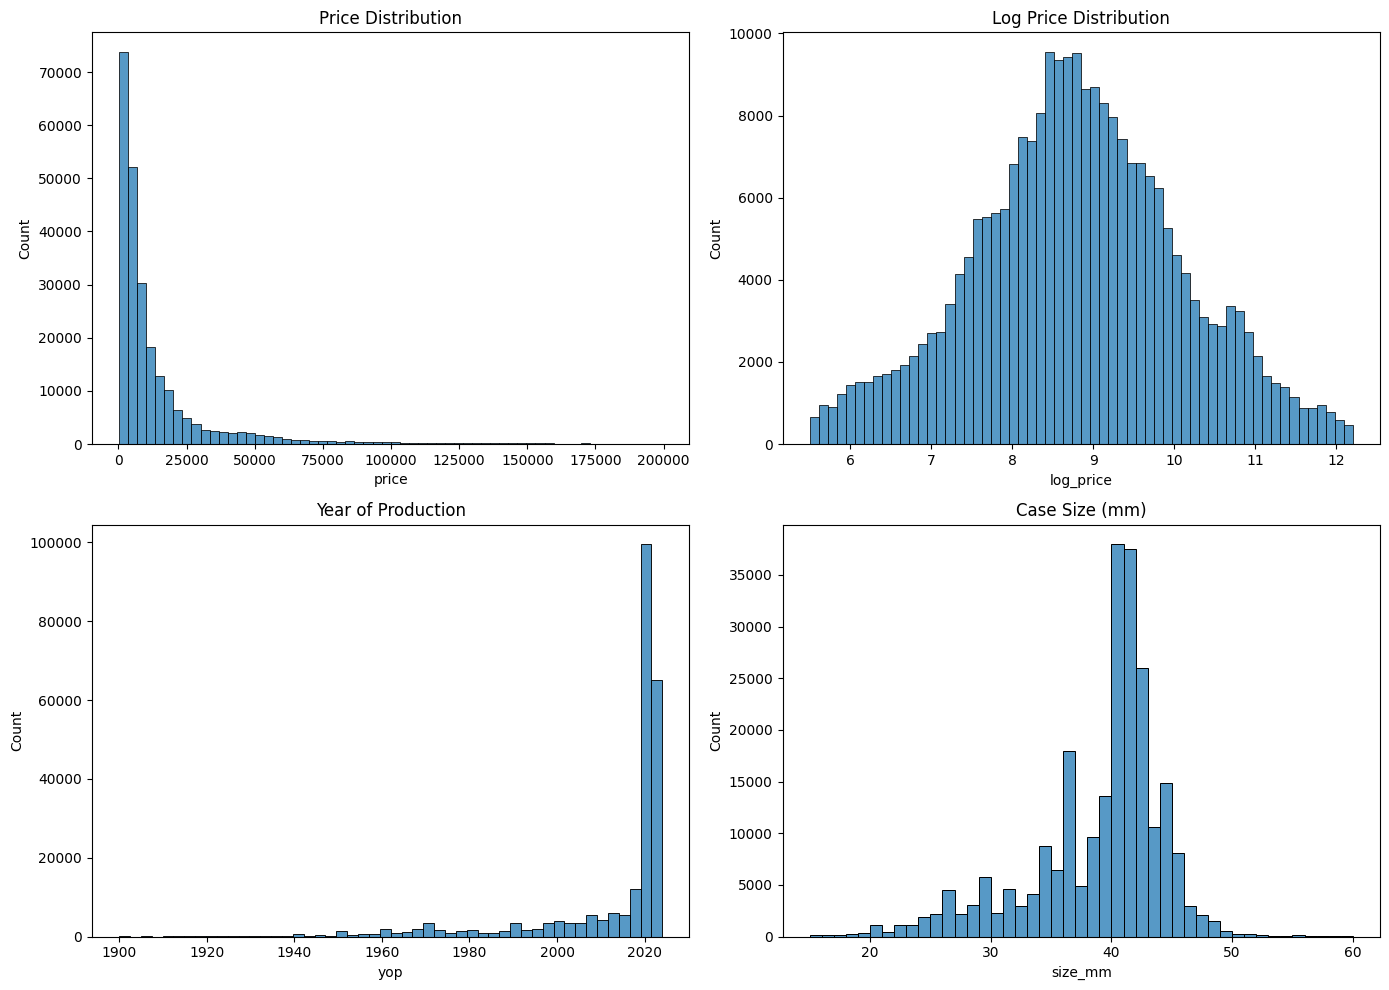

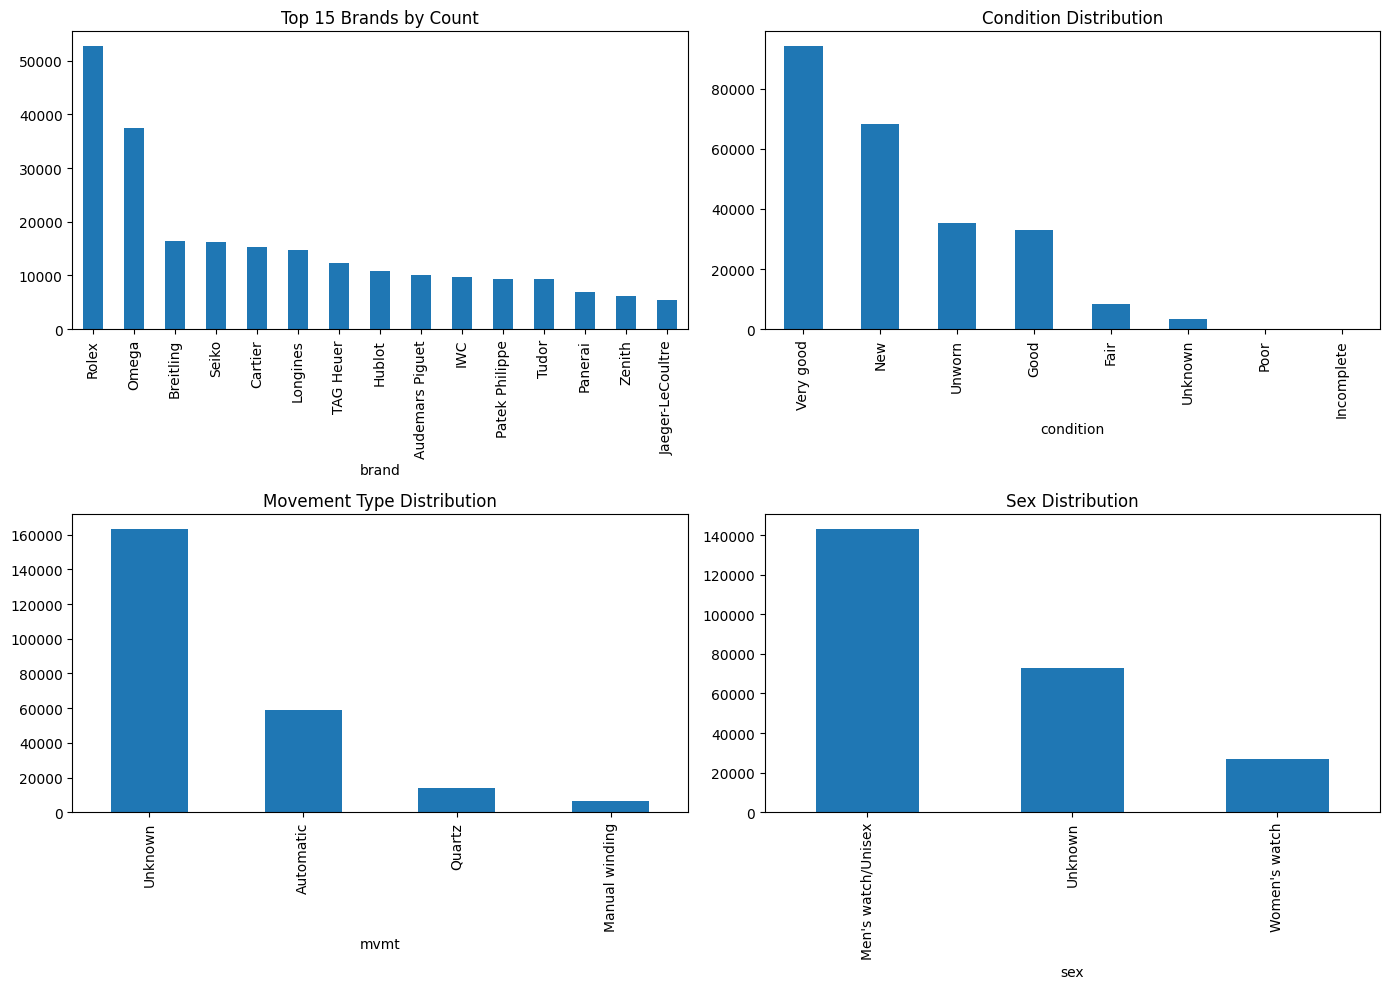

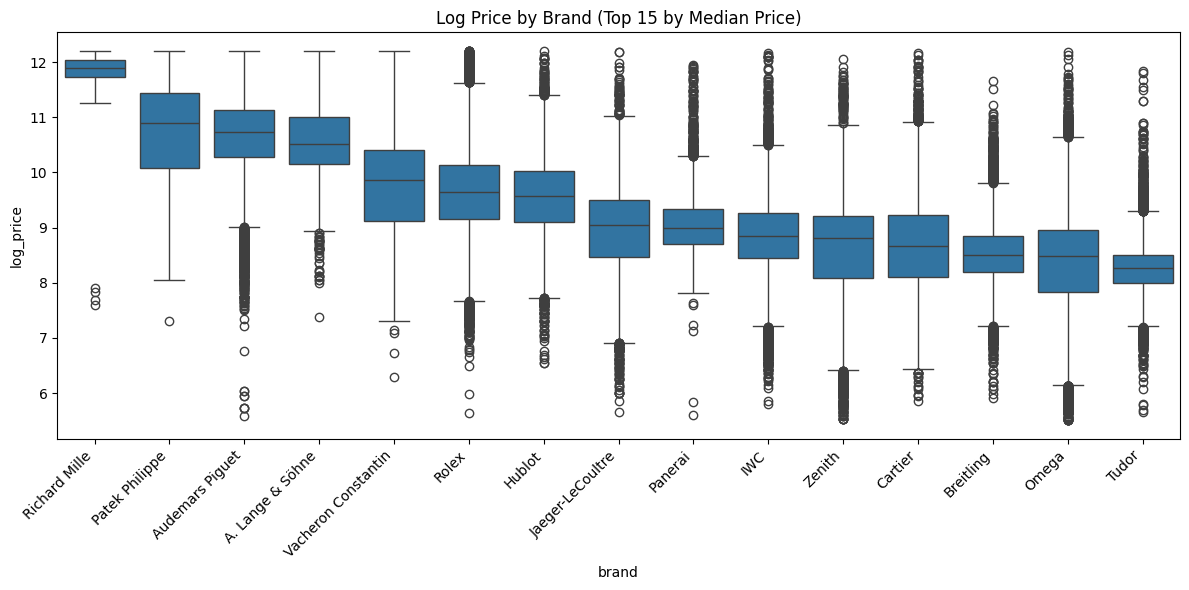

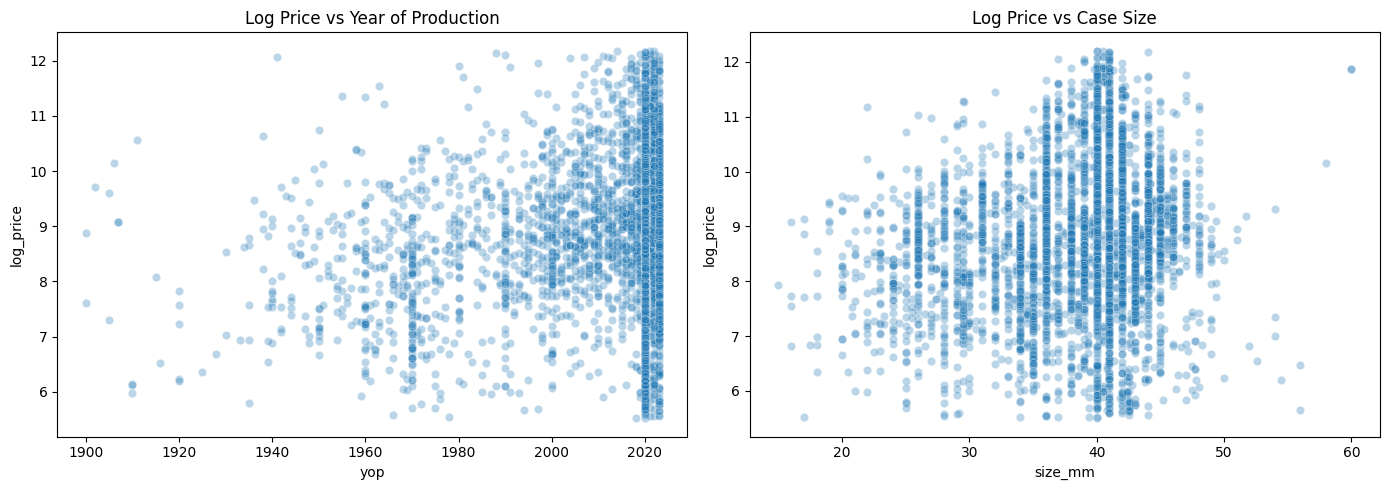

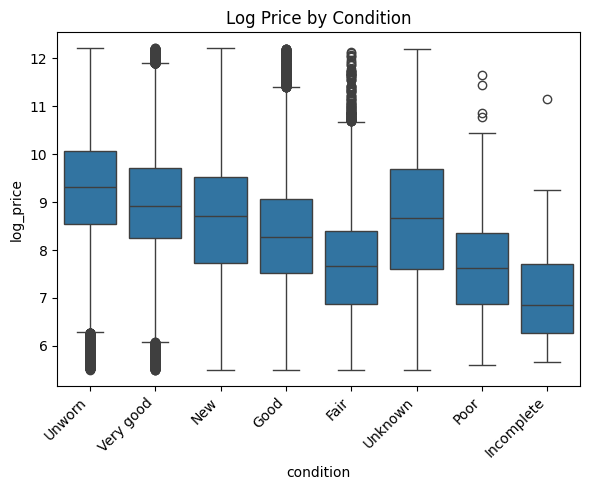

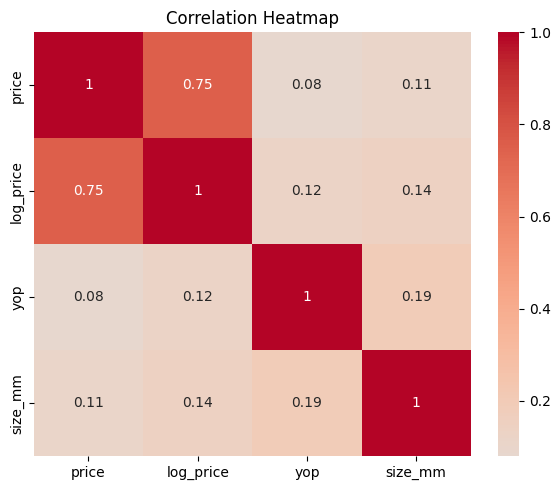

Shape: (242926, 24)

Brand counts (top 10):
brand
Rolex              52826
Omega              37489
Breitling          16373
Seiko              16183
Cartier            15280
Longines           14676
TAG Heuer          12338
Hublot             10888
Audemars Piguet    10023
IWC                 9626
Name: count, dtype: int64

Condition counts:
condition
Very good     94340
New           68150
Unworn        35437
Good          32962
Fair           8405
Unknown        3422
Poor            170
Incomplete       40
Name: count, dtype: int64

Correlation with log_price:
log_price    1.000000
price        0.749718
size_mm      0.142013
yop          0.123706
Name: log_price, dtype: float64


In [8]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['price'], bins=60, ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution')
sns.histplot(df['log_price'], bins=60, ax=axes[0, 1])
axes[0, 1].set_title('Log Price Distribution')
sns.histplot(df['yop'].dropna(), bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Year of Production')
sns.histplot(df['size_mm'].dropna(), bins=45, ax=axes[1, 1])
axes[1, 1].set_title('Case Size (mm)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['brand'].value_counts().head(15).plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Top 15 Brands by Count')
df['condition'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Condition Distribution')
df['mvmt'].value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Movement Type Distribution')
df['sex'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Sex Distribution')
plt.tight_layout()
plt.show()

top_brands = df.groupby('brand')['price'].median().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='log_price', order=top_brands)
plt.xticks(rotation=45, ha='right')
plt.title('Log Price by Brand (Top 15 by Median Price)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(min(5000, len(df))), x='yop', y='log_price', alpha=0.3, ax=axes[0])
axes[0].set_title('Log Price vs Year of Production')
sns.scatterplot(data=df.sample(min(5000, len(df))), x='size_mm', y='log_price', alpha=0.3, ax=axes[1])
axes[1].set_title('Log Price vs Case Size')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='condition', y='log_price')
plt.xticks(rotation=45, ha='right')
plt.title('Log Price by Condition')
plt.tight_layout()
plt.show()

numeric_cols = ['price', 'log_price', 'yop', 'size_mm']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print(f"Shape: {df.shape}")
print(f"\nBrand counts (top 10):\n{df['brand'].value_counts().head(10)}")
print(f"\nCondition counts:\n{df['condition'].value_counts()}")
print(f"\nCorrelation with log_price:\n{corr['log_price'].abs().sort_values(ascending=False)}")

# Feature Engineering

In [9]:
base_features = ['yop', 'size_mm', 'watch_age', 'yop_missing', 'size_missing',
                  'same_material', 'precious_case', 'precious_brace',
                  'name_len', 'name_missing', 'has_limited', 'model_freq',
                  'brand', 'mvmt', 'casem', 'bracem', 'sex', 'condition']

print(f"Features used for modeling ({len(base_features)}):")
print(base_features)

CURRENT_YEAR = 2026

df['watch_age'] = CURRENT_YEAR - df['yop']
df['yop_missing'] = df['yop'].isna().astype(int)
df['size_missing'] = df['size_mm'].isna().astype(int)
df['yop'] = df['yop'].fillna(df['yop'].median())
df['size_mm'] = df['size_mm'].fillna(df.groupby('sex')['size_mm'].transform('median'))
df['watch_age'] = df['watch_age'].fillna(df['watch_age'].median())

df['same_material'] = (df['casem'] == df['bracem']).astype(int)
gold_pattern = 'gold|platinum'
df['precious_case'] = df['casem'].str.contains(gold_pattern, case=False, na=False).astype(int)
df['precious_brace'] = df['bracem'].str.contains(gold_pattern, case=False, na=False).astype(int)

df['name_len'] = df['name'].fillna('').str.len()
df['name_missing'] = df['name'].isna().astype(int)
df['has_limited'] = df['name'].fillna('').str.contains('limited|anniversary|edition', case=False).astype(int)

rare_brands = df['brand'].value_counts()[df['brand'].value_counts() < 10].index
df['brand'] = df['brand'].replace(rare_brands, 'Other')

model_freq = df['model'].value_counts(normalize=True)
df['model_freq'] = df['model'].map(model_freq)

df_encoded = pd.get_dummies(df, columns=['brand', 'mvmt', 'casem', 'bracem', 'sex', 'condition'],
                            drop_first=True, dtype=int)

drop_cols = ['name', 'model', 'ref', 'price']
X = df_encoded.drop(columns=drop_cols + ['log_price'])
y = df_encoded['log_price']

print(f"\nX shape (after one-hot expansion): {X.shape}")
print(f"\nAny NaN left: {X.isnull().sum().sum()}")
print(f"\nTop correlations with log_price:\n{df_encoded[X.select_dtypes(include=np.number).columns.tolist() + ['log_price']].corr()['log_price'].abs().sort_values(ascending=False).head(15)}")

Features used for modeling (18):
['yop', 'size_mm', 'watch_age', 'yop_missing', 'size_missing', 'same_material', 'precious_case', 'precious_brace', 'name_len', 'name_missing', 'has_limited', 'model_freq', 'brand', 'mvmt', 'casem', 'bracem', 'sex', 'condition']

X shape (after one-hot expansion): (242926, 85)

Any NaN left: 0

Top correlations with log_price:
log_price                1.000000
brand_Seiko              0.437170
brand_Rolex              0.356408
name_missing             0.356099
brand_Patek Philippe     0.301980
brand_Audemars Piguet    0.298024
precious_case            0.290544
sex_Unknown              0.279656
brand_Longines           0.258697
model_freq               0.211570
precious_brace           0.209008
casem_Rose gold          0.200400
brand_TAG Heuer          0.182233
name_len                 0.180987
mvmt_Quartz              0.161155
Name: log_price, dtype: float64
